# Report 2: Exploration of energy usage and devices

This report aims to answer the following questions:

- Which months have higher energy and gas usage?
- What patterns emerge from gas and electricity usage over time? (Cluster analysis)


In [132]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
import datetime
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

First lets insert the files into the database

In [133]:
db.erase_table_content("P1e")
files = check_filepaths("P1e-*.csv.gz","P1e") + check_filepaths("P1e-*.csv","P1e")
for file in files:
    db.insert_table_P1e(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table P1e deleted successfully


In [134]:
db.erase_table_content("smartthings")
files = check_filepaths("smartthings*.tsv.gz","smartthings")

for file in files:
    db.insert_table_smartthings(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table smartthings deleted successfully


In [135]:
db.erase_table_content("P1g")
files = check_filepaths("P1g-*.csv.gz","P1g") + check_filepaths("P1g-*.csv","P1g")
for file in files:
    db.insert_table_P1g(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table P1g deleted successfully


And now fetch them and insert them into a pandas dataframe

In [136]:
smart_things = db.return_whole_table("smartthings")
p1e = db.return_whole_table("P1e")
p1g = db.return_whole_table("P1g")

Prepare data:

In [137]:
p1e["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1e["year"] = p1e["date"].dt.year
p1e["month"] = p1e["date"].dt.month
p1e["day_as_date"]=p1e["date"].dt.date
p1e["Usage"] = (p1e["Electricity_imported_T1"].diff() + p1e["Electricity_imported_T2"].diff()).fillna(0)

p1g["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1g["year"] = p1g["date"].dt.year
p1g["month"] = p1g["date"].dt.month
p1g["day_as_date"]=p1g["date"].dt.date
p1g["Usage"] = (p1g["Total_gas_used"].diff()).fillna(0)

p1e_new = p1e.groupby(by=["day_as_date","year","month"], as_index = False)["Usage"].aggregate(total_usage_electricity = "sum")
p1g_new = p1g.groupby(by=["day_as_date","year","month"], as_index = False)["Usage"].aggregate(total_usage_gas = "sum")

df = p1e_new.merge(p1g_new, how = "outer", on = ["day_as_date", "year", "month"])

## Electricity and gas usage over the months

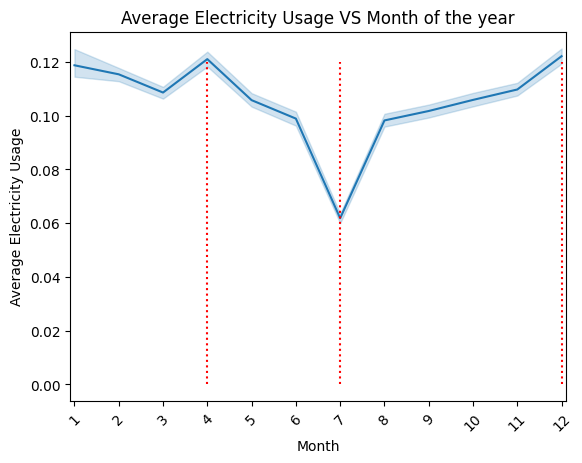

In [ ]:
ax = sns.lineplot(p1e, x = "month", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,13, step = 1), rotation = 0, labels = range(0,13,1))
plt.xlim(0.9, 12.1)
plt.vlines(x = [4,12,7], ymin = 0, ymax= 0.12, linestyles= "dotted", color = "red")
ax.set(xlabel = "Month", ylabel = "Average Electricity Usage", title = "Average Electricity Usage VS Month of the year")
plt.show()

We see that energy consumption is higher in the months of April and December, and at it's lowest in the month of July. 

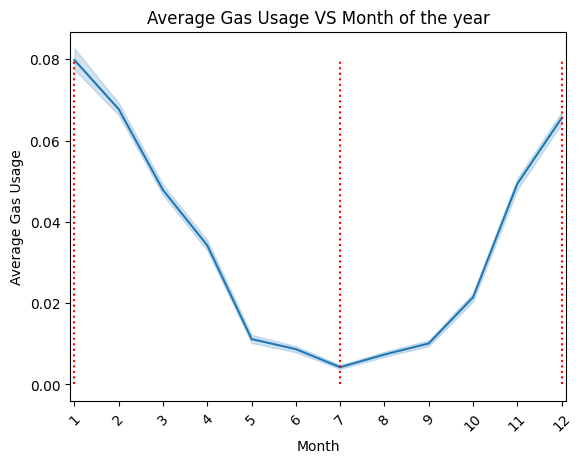

In [ ]:
ax = sns.lineplot(p1g, x = "month", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,13, step = 1), rotation = 0, labels = range(0,13,1))
plt.xlim(0.9, 12.1)
plt.vlines(x = [1,12,7], ymin = 0, ymax= 0.08, linestyles= "dotted", color = "red")
ax.set(xlabel = "Month", ylabel = "Average Gas Usage", title = "Average Gas Usage VS Month of the year")
plt.show()

As expected we can see the consumption of gas is on average higher on the colder months, and lower in the summer months, since then no heating is used.

## K means clustering

### Scree plot

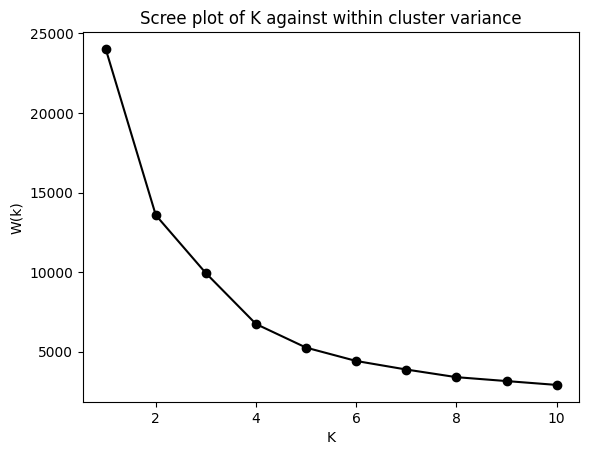

In [ ]:
from sklearn.cluster import KMeans
ss = []

for i in range(1,11):
    k = KMeans(n_clusters = i, random_state=42).fit(df[["total_usage_gas","total_usage_electricity"]])
    ss.append(k.inertia_)

plt.plot([i for i in range(1,11)], ss, 'o-', color = "black")
plt.title("Scree plot of K against within cluster variance")
plt.xlabel("K")
plt.ylabel("WCV")
plt.show()


To decide on the number of clusters, we can use the scree plot where we plot the number of clusters (k) against the Within Cluster variance (WCV). We aim to minimize the WCV while choosing the smallest k, for which we can look at the lowest k that generates a significant drop in WCV, this is known as the "elbow" (because of the line's shape). From the scree plot we can see the "elbow" is located around k = 4, so we'll choose to have 4 clusters. 

In [141]:
model = KMeans(n_clusters = 4,random_state = 42).fit(df[["total_usage_gas","total_usage_electricity"]])
label = model.predict(df[["total_usage_gas","total_usage_electricity"]])
p1e_new["label"] = label

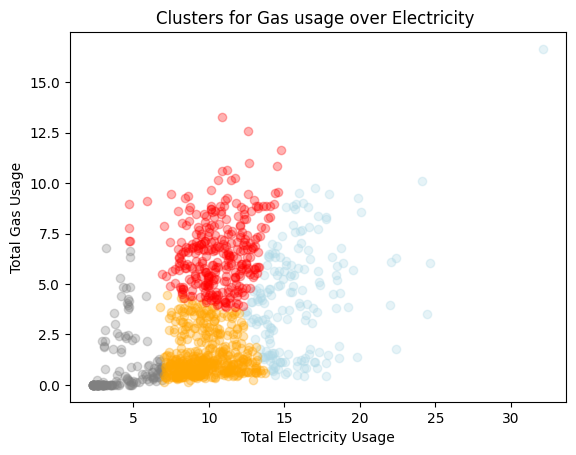

In [142]:

plt.scatter(df.loc[label == 0, "total_usage_electricity"], df.loc[label == 0, "total_usage_gas"], color = "lightblue", alpha = 0.3)
plt.scatter(df.loc[label == 1, "total_usage_electricity"], df.loc[label == 1, "total_usage_gas"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "total_usage_electricity"], df.loc[label == 2, "total_usage_gas"], color = "orange", alpha = 0.3)
plt.scatter(df.loc[label == 3, "total_usage_electricity"], df.loc[label == 3, "total_usage_gas"], color = "red", alpha = 0.3)
plt.title("Clusters for Gas usage over Electricity ")
plt.xlabel("Total Electricity Usage")
plt.ylabel("Total Gas Usage")
plt.show()

After performing k-means clustering using k = 4, we obtain the following groups:

- Gray: days when both electricity and gas usage are low, possibly indicating these are days where the family was not at home.
- Blue: days when electricity usage was high.
- Yellow: days with average electricity use paired with low gas use.
- Red: days with average electricity use with high gas use.

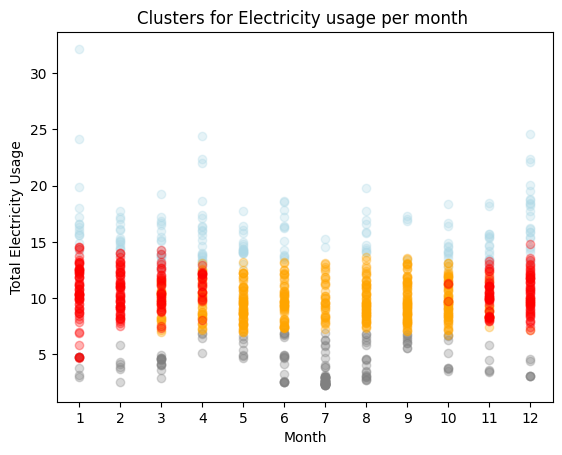

In [143]:
plt.scatter(df.loc[label == 0, "month"], df.loc[label == 0, "total_usage_electricity"], color = "lightblue", alpha = 0.3)
plt.scatter(df.loc[label == 1, "month"], df.loc[label == 1, "total_usage_electricity"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "month"], df.loc[label == 2, "total_usage_electricity"], color = "orange", alpha = 0.3)
plt.scatter(df.loc[label == 3, "month"], df.loc[label == 3, "total_usage_electricity"], color = "red", alpha = 0.3)
plt.title("Clusters for Electricity usage per month ")
plt.xticks(np.arange(1,13, step = 1), rotation = 0, labels = range(1,13,1))
plt.xlabel("Month")
plt.ylabel("Total Electricity Usage")
plt.show()


We can see here the yellow group (average electricity, low gas) is mainly comprised of the summer months, while the red group (average electricity, high gas) is located around the winter months; both clusters are reasonable in the context of the data because given temperatures are higher in the summer, heating isn't widely used, in contrast to the winter months when gas usage increases because of the need for heating. 

For the case of gray and blue groups these just mark the days of very low general consumption and very high general consumption, respectively.

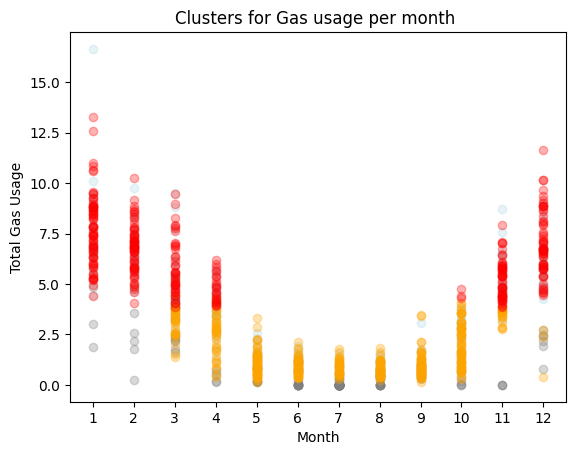

In [144]:
plt.scatter(df.loc[label == 0, "month"], df.loc[label == 0, "total_usage_gas"], color = "lightblue", alpha = 0.3)
plt.scatter(df.loc[label == 1, "month"], df.loc[label == 1, "total_usage_gas"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "month"], df.loc[label == 2, "total_usage_gas"], color = "orange", alpha = 0.3)
plt.scatter(df.loc[label == 3, "month"], df.loc[label == 3, "total_usage_gas"], color = "red", alpha = 0.3)

plt.title("Clusters for Gas usage per month ")
plt.xticks(np.arange(1,13, step = 1), rotation = 0, labels = range(1,13,1))
plt.xlabel("Month")
plt.ylabel("Total Gas Usage")
plt.show()

Similarly as for electricity, in this case we can observe the yellow group (average electricity, low gas) is mainly comprised of the summer months, while the red group (average electricity, high gas) is located around the winter months. For the case of gray and blue groups these simply mark the days of very low electricity consumption and very high electricity consumption, respectively.